# Compare Sr wavefunctions for different model potentials

In [1]:
import logging

import matplotlib.pyplot as plt

from rydstate import RydbergStateSQDTAlkalineLS

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(filename)s: %(message)s")
logging.getLogger("rydstate").setLevel(logging.DEBUG)

In [2]:
model_potentials = [
    "coulomb",
    "model_potential_marinescu_1993",
    "model_potential_fei_2009",
    "potential_kostelecky_1985",
]

states_19s: dict[str, RydbergStateSQDTAlkalineLS] = {}
for model_potential in model_potentials:
    state = RydbergStateSQDTAlkalineLS("Sr88", n=19, l=0, j_tot=1, s_tot=1, m=1)
    state.radial.create_model(potential_type=model_potential)
    state.radial.create_wavefunction(sign_convention="positive_at_outer_bound")
    states_19s[model_potential] = state

states_5p: dict[str, RydbergStateSQDTAlkalineLS] = {}
for model_potential in model_potentials:
    state = RydbergStateSQDTAlkalineLS("Sr88", n=5, l=1, j_tot=1, s_tot=1, m=1)
    state.radial.create_model(potential_type=model_potential)
    state.radial.create_wavefunction(sign_convention="positive_at_outer_bound")
    states_5p[model_potential] = state

WARNING wavefunction.py: The wavefunction for the state RadialKet(Sr88, nu=15.627514314041266, l_r=0, (n=19)) has some issues:
      The wavefunction has 15 nodes, but should have 18 nodes.
      The integration for l=0 did stop at 0.31 (should be close to zero).
WARNING wavefunction.py: The wavefunction for the state RadialKet(Sr88, nu=15.627514314041266, l_r=0, (n=19)) has some issues:
      The wavefunction has 14 nodes, but should have 18 nodes.
      The integration for l=0 did stop at 1.6600000000000001 (should be close to zero).
WARNING wavefunction.py: The wavefunction for the state RadialKet(Sr88, nu=15.627514314041266, l_r=0, (n=19)) has some issues:
      The wavefunction has 14 nodes, but should have 18 nodes.
WARNING wavefunction.py: The wavefunction for the state RadialKet(Sr88, nu=1.8686151642220648, l_r=1, (n=5)) has some issues:
      The wavefunction is not close to zero at the inner boundary (inner_weight_scaled_to_whole_grid=1.59e+00)
      The wavefunction has 0 no

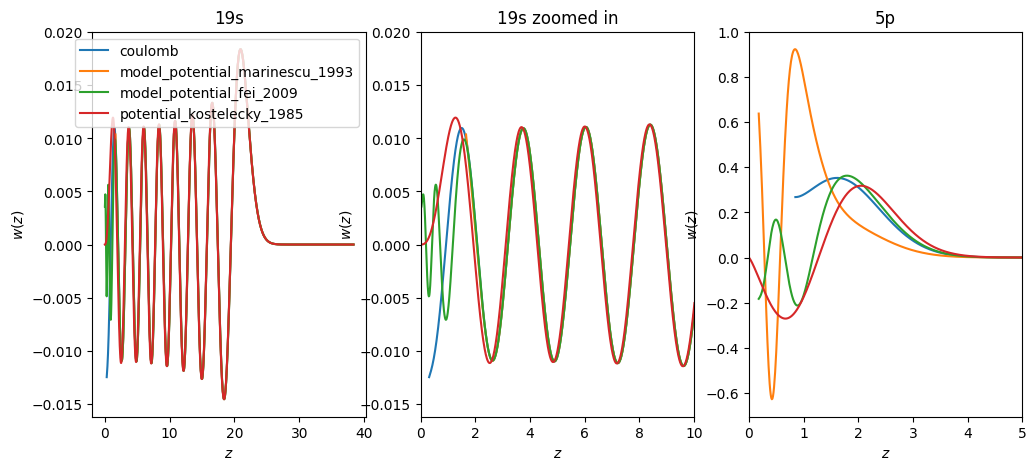

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(12, 5))

axs[0].set_title("19s")
for model_potential, state in states_19s.items():
    wavefunction = state.radial.wavefunction
    axs[0].plot(wavefunction.grid.z_list, wavefunction.w_list, label=model_potential)

axs[1].set_title("19s zoomed in")
for model_potential, state in states_19s.items():
    wavefunction = state.radial.wavefunction
    axs[1].plot(wavefunction.grid.z_list, wavefunction.w_list, label=model_potential)
axs[1].set_xlim(0, 10)

axs[2].set_title("5p")
for model_potential, state in states_5p.items():
    wavefunction = state.radial.wavefunction
    axs[2].plot(wavefunction.grid.z_list, wavefunction.w_list, label=model_potential)
axs[2].set_xlim(0, 5)

for ax in axs:
    ax.set_xlabel(r"$z$")
    ax.set_ylabel(r"$w(z)$")

axs[0].legend()
plt.show()